# Deep-Learning Assisted Eigenmode Retrieval

We attempt to make predictions on subsequent turbulence eigenmodes with the help of deep learning. We use a Fourier Neural Operator, which is well suited to learn nonlinear functions which applies transformations in the fourier domain.

In [171]:
import torch
import torch.nn as nn
import os
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
from LightPipes import *

import fno
from fno import FNO2d, spectral_relative_l2, make_freq_weights, overlap_loss

# Begin by loading up the dataset

Alternatively, load from a pre-converted `.npz` file (much faster — run `convert_dataset_to_npz.py` first).

In [172]:

NPZ_PATH = "datasets/dataset2.npz"   # ← path to the pre-converted .npz file

npz = np.load(NPZ_PATH)
data = {k: npz[k] for k in npz.files}

print(f"Loaded dataset from '{NPZ_PATH}'")
print(f"Keys    : {list(data.keys())}")
print(f"Samples : {data['gaussian_forward_real'].shape[0]}")
print(f"Grid    : {data['gaussian_forward_real'].shape[1:]} (H x W)")


Loaded dataset from 'datasets/dataset2.npz'
Keys    : ['eigenmode_1_real', 'eigenmode_2_real', 'eigenmode_3_real', 'eigenmode_4_real', 'eigenmode_1_imag', 'eigenmode_2_imag', 'eigenmode_3_imag', 'eigenmode_4_imag', 'gaussian_forward_real', 'gaussian_forward_imag', 'gaussian_reversed_real', 'gaussian_reversed_imag']
Samples : 10001
Grid    : (64, 64) (H x W)


For each time step, we have information about four turbulence eigenmodes, as well as the gaussian mode going forwards and backwards.

The samples in our dataset must be prepared as single-step predictors, meaning that they are input-output pairs of the form $(E_{t}, P_{t+1}) \rightarrow E_{t+1}$

In [3]:
N_EIGENMODES = 1

def normalize_11(arr: np.ndarray) -> np.ndarray:
    """Min-max normalise arr to the range [-1, +1]."""
    lo, hi = arr.min(), arr.max()
    if hi - lo < 1e-12:          # constant array — avoid division by zero
        return np.zeros_like(arr)
    return 2.0 * (arr - lo) / (hi - lo) - 1.0

def prepare_pairs(data, n_eigenmodes=N_EIGENMODES):
    """
    Build single-step predictor pairs from the dataset.

    For each consecutive pair of timesteps (t, t+1) and each eigenmode k we form:
      - Input  : [eigenmode_k_real_t,        eigenmode_k_imag_t,
                  gaussian_forward_real_t+1,  gaussian_forward_imag_t+1,
                  gaussian_reversed_real_t+1, gaussian_reversed_imag_t+1]  → (H, W, 6)
      - Target : [eigenmode_k_real_{t+1}, eigenmode_k_imag_{t+1}]          → (H, W, 2)

    Samples are interleaved by timestep (outer) then eigenmode (inner), matching
    prepare_pairs_slow, so that a simple train/test slice gives a proper temporal holdout:
      row index = t * n_eigenmodes + (k - 1)

    The Gaussian forward/reversed channels are normalised to [-1, +1].

    Returns
    -------
    X : torch.Tensor  shape ((N-1)*n_eigenmodes, H, W, 6)
    Y : torch.Tensor  shape ((N-1)*n_eigenmodes, H, W, 2)
    """
    N_samples = data["gaussian_forward_real"].shape[0]
    H, W      = data["gaussian_forward_real"].shape[1:]
    N_pairs   = N_samples - 1
    total     = N_pairs * n_eigenmodes

    # Pre-allocate output arrays
    X = np.empty((total, H, W, 6), dtype=np.float32)
    Y = np.empty((total, H, W, 2), dtype=np.float32)

    # Load and normalise Gaussian arrays once — shared across all eigenmodes
    gfwd_real = normalize_11(data["gaussian_forward_real"][1:].astype(np.float32))  # (N-1, H, W)
    gfwd_imag = normalize_11(data["gaussian_forward_imag"][1:].astype(np.float32))
    grev_real = normalize_11(data["gaussian_reversed_real"][1:].astype(np.float32))
    grev_imag = normalize_11(data["gaussian_reversed_imag"][1:].astype(np.float32))

    # Load all eigenmode arrays up front
    em = {}
    for k in range(1, n_eigenmodes + 1):
        em[k] = (data[f"eigenmode_{k}_real"].astype(np.float32),
                 data[f"eigenmode_{k}_imag"].astype(np.float32))

    # Fill in timestep-major order: row = t * n_eigenmodes + (k-1)
    for t in range(N_pairs):
        for k in range(1, n_eigenmodes + 1):
            row = t * n_eigenmodes + (k - 1)
            em_real, em_imag = em[k]

            X[row, ..., 0] = em_real[t]       # eigenmode k at t
            X[row, ..., 1] = em_imag[t]
            X[row, ..., 2] = gfwd_real[t]     # Gaussian forward at t+1  (normalised)
            X[row, ..., 3] = gfwd_imag[t]
            X[row, ..., 4] = grev_real[t]     # Gaussian reversed at t+1 (normalised)
            X[row, ..., 5] = grev_imag[t]

            Y[row, ..., 0] = em_real[t + 1]   # eigenmode k at t+1
            Y[row, ..., 1] = em_imag[t + 1]

        if (t + 1) % 50 == 0 or (t + 1) == N_pairs:
            print(f"  Processed {t+1}/{N_pairs} timestep pairs ...")

    return torch.from_numpy(X), torch.from_numpy(Y)

X, Y = prepare_pairs(data)

print(f"Input  shape : {X.shape}")   # ((N-1)*4, H, W, 6)
print(f"Target shape : {Y.shape}")   # ((N-1)*4, H, W, 2)


  Processed 50/10000 timestep pairs ...
  Processed 100/10000 timestep pairs ...
  Processed 150/10000 timestep pairs ...
  Processed 200/10000 timestep pairs ...
  Processed 250/10000 timestep pairs ...
  Processed 300/10000 timestep pairs ...
  Processed 350/10000 timestep pairs ...
  Processed 400/10000 timestep pairs ...
  Processed 450/10000 timestep pairs ...
  Processed 500/10000 timestep pairs ...
  Processed 550/10000 timestep pairs ...
  Processed 600/10000 timestep pairs ...
  Processed 650/10000 timestep pairs ...
  Processed 700/10000 timestep pairs ...
  Processed 750/10000 timestep pairs ...
  Processed 800/10000 timestep pairs ...
  Processed 850/10000 timestep pairs ...
  Processed 900/10000 timestep pairs ...
  Processed 950/10000 timestep pairs ...
  Processed 1000/10000 timestep pairs ...
  Processed 1050/10000 timestep pairs ...
  Processed 1100/10000 timestep pairs ...
  Processed 1150/10000 timestep pairs ...
  Processed 1200/10000 timestep pairs ...
  Processed 

In [79]:
def normalize_11(arr: np.ndarray) -> np.ndarray:
    """Min-max normalise arr to the range [-1, +1]."""
    lo, hi = arr.min(), arr.max()
    if hi - lo < 1e-12:          # constant array — avoid division by zero
        return np.zeros_like(arr)
    return 2.0 * (arr - lo) / (hi - lo) - 1.0


# ── Original (slow) version — kept for reference ──────────────────────────────
# Builds X and Y by appending to Python lists then stacking at the end.
# Equivalent output to prepare_pairs() above, but uses more memory and is slower.


def prepare_pairs_slow(data, n_eigenmodes=N_EIGENMODES):
    """
    Original list-based implementation of prepare_pairs.

    For each consecutive pair of timesteps (t, t+1) and each eigenmode k:
      - Input  : [normalize(eigenmode_k_real_t),        normalize(eigenmode_k_imag_t),
                  normalize(gaussian_forward_real_t+1),  normalize(gaussian_forward_imag_t+1),
                  normalize(gaussian_reversed_real_t+1), normalize(gaussian_reversed_imag_t+1)]
      - Target : [normalize(eigenmode_k_real_{t+1}), normalize(eigenmode_k_imag_{t+1})]

    All channels are independently normalised to [-1, +1] via normalize_11.
    """
    N_samples = data["gaussian_forward_real"].shape[0]

    X_list = []
    Y_list = []

    for t in range(N_samples - 1):
        gfwd_real = data["gaussian_forward_real"][t].astype(np.float32)
        gfwd_imag = data["gaussian_forward_imag"][t].astype(np.float32)
        grev_real = data["gaussian_reversed_real"][t].astype(np.float32)
        grev_imag = data["gaussian_reversed_imag"][t].astype(np.float32)

        for k in range(1, n_eigenmodes + 1):
            em_real_t  = data[f"eigenmode_{k}_real"][t].astype(np.float32)
            em_imag_t  = data[f"eigenmode_{k}_imag"][t].astype(np.float32)
            em_real_t1 = data[f"eigenmode_{k}_real"][t+1].astype(np.float32)
            em_imag_t1 = data[f"eigenmode_{k}_imag"][t+1].astype(np.float32)

            x = np.stack([em_real_t, em_imag_t,
                          gfwd_real, gfwd_imag,
                          grev_real, grev_imag], axis=-1)   # (H, W, 6)
            y = np.stack([em_real_t1, em_imag_t1], axis=-1) # (H, W, 2)

            X_list.append(x)
            Y_list.append(y)

        if (t + 1) % 50 == 0 or (t + 1) == N_samples - 1:
            print(f"  Processed {t+1}/{N_samples - 1} timestep pairs ...")

    X = torch.from_numpy(np.stack(X_list, axis=0))
    Y = torch.from_numpy(np.stack(Y_list, axis=0))
    return X, Y

# Uncomment to use the slow version instead:
X, Y = prepare_pairs_slow(data)
print(f"Input  shape : {X.shape}")
print(f"Target shape : {Y.shape}")


  Processed 50/10000 timestep pairs ...
  Processed 100/10000 timestep pairs ...
  Processed 150/10000 timestep pairs ...
  Processed 200/10000 timestep pairs ...
  Processed 250/10000 timestep pairs ...
  Processed 300/10000 timestep pairs ...
  Processed 350/10000 timestep pairs ...
  Processed 400/10000 timestep pairs ...
  Processed 450/10000 timestep pairs ...
  Processed 500/10000 timestep pairs ...
  Processed 550/10000 timestep pairs ...
  Processed 600/10000 timestep pairs ...
  Processed 650/10000 timestep pairs ...
  Processed 700/10000 timestep pairs ...
  Processed 750/10000 timestep pairs ...
  Processed 800/10000 timestep pairs ...
  Processed 850/10000 timestep pairs ...
  Processed 900/10000 timestep pairs ...
  Processed 950/10000 timestep pairs ...
  Processed 1000/10000 timestep pairs ...
  Processed 1050/10000 timestep pairs ...
  Processed 1100/10000 timestep pairs ...
  Processed 1150/10000 timestep pairs ...
  Processed 1200/10000 timestep pairs ...
  Processed 

In [226]:

# ── Delta version ──────────────────────────────────────────────────────────────
# Instead of predicting E_{t+1} directly, the network predicts the *change*
#   ΔE = E_{t+1} − E_t
# so the target is a residual rather than the absolute field.
# The next eigenmode is then reconstructed as:
#   E_{t+1} ≈ E_t + ΔE_pred

def prepare_pairs_delta(data, n_eigenmodes=N_EIGENMODES, include_lag = False, lag=1):
    """
    Build single-step *delta* predictor pairs with extended probe context.

    For each consecutive pair (t → t+1), with t starting from `lag` to allow
    access to t-lag, and each eigenmode k the input has 11 channels:

      ch  0,1  : norm(em_k_real_t),    norm(em_k_imag_t)    eigenmode at t  (normalised)
      ch  2,3  : P→(t)   Re/Im  = gaussian_forward[t]        current forward probe
      ch  4,5  : P←(t)   Re/Im  = gaussian_reversed[t]       current reverse probe
      ch  6,7  : P→(t-N) Re/Im  = gaussian_forward[t-lag]    lagged forward probe
      ch  8,9  : P←(t-N) Re/Im  = gaussian_reversed[t-lag]   lagged reverse probe
      ch 10    : ΔI→(t,N) = I→(t) − I→(t-lag)               forward frame difference

    Target (2 channels):
      normalised delta  norm(em_k_{t+1}) − norm(em_k_t)

    Parameters
    ----------
    lag : int
        Number of frames to look back for the lagged probe channels and frame
        difference (default 1, i.e. t-1).  The loop starts at t=lag so that
        t-lag is always a valid index, yielding (N_samples - lag - 1) pairs.

    Returns
    -------
    X : torch.Tensor  shape ((N-lag-1)*n_eigenmodes, H, W, 11)
    Y : torch.Tensor  shape ((N-lag-1)*n_eigenmodes, H, W,  2)  ← normalised residuals
    """
    N_samples = data["gaussian_forward_real"].shape[0]
    H, W      = data["gaussian_forward_real"].shape[1:]
    N_pairs   = N_samples - lag - 1   # t runs from lag to N_samples-2 inclusive
    total     = N_pairs * n_eigenmodes

    if (include_lag):
        X = np.empty((total, H, W, 11), dtype=np.float32)
    else: 
        X = np.empty((total, H, W, 6), dtype=np.float32)

    Y = np.empty((total, H, W,  2), dtype=np.float32)

    # ── Load all Gaussian probe arrays (full time axis) ───────────────────────
    gfwd_real = data["gaussian_forward_real"].astype(np.float32)    # (N, H, W)
    gfwd_imag = data["gaussian_forward_imag"].astype(np.float32)
    grev_real = data["gaussian_reversed_real"].astype(np.float32)
    grev_imag = data["gaussian_reversed_imag"].astype(np.float32)

    # ── Forward intensity I→(t) = |P→(t)|²  ──────────────────────────────────
    fwd_intensity = gfwd_real ** 2 + gfwd_imag ** 2                 # (N, H, W)

    # ── Eigenmode arrays: raw for delta targets, normalised for inputs ────────
    em_raw  = {}
    em_norm = {}
    for k in range(1, n_eigenmodes + 1):
        raw_r = data[f"eigenmode_{k}_real"].astype(np.float32)
        raw_i = data[f"eigenmode_{k}_imag"].astype(np.float32)
        em_raw[k]  = (raw_r, raw_i)
        em_norm[k] = (normalize_11(raw_r), normalize_11(raw_i))

    # ── Fill arrays — t runs from lag to N_samples-2 ─────────────────────────
    for t in range(lag, N_samples - 1):
        pair_idx = t - lag   # 0-based row offset
        for k in range(1, n_eigenmodes + 1):
            row = pair_idx * n_eigenmodes + (k - 1)
            raw_r,  raw_i  = em_raw[k]
            norm_r, norm_i = em_norm[k]

            # ch 0,1 — normalised eigenmode at t
            X[row, ..., 0] = norm_r[t]
            X[row, ..., 1] = norm_i[t]

            # ch 2,3 — current forward probe P→(t)
            X[row, ..., 2] = gfwd_real[t]
            X[row, ..., 3] = gfwd_imag[t]

            # ch 4,5 — current reverse probe P←(t)
            X[row, ..., 4] = grev_real[t]
            X[row, ..., 5] = grev_imag[t]

            if (include_lag): # Include previous Gaussian probes to get temporal data
                # ch 6,7 — lagged forward probe P→(t-N)
                X[row, ..., 6] = gfwd_real[t - lag]
                X[row, ..., 7] = gfwd_imag[t - lag]

                # ch 8,9 — lagged reverse probe P←(t-N)
                X[row, ..., 8] = grev_real[t - lag]
                X[row, ..., 9] = grev_imag[t - lag]

                # ch 10 — forward frame difference ΔI→(t,N) = I→(t) − I→(t-N)
                X[row, ..., 10] = fwd_intensity[t] - fwd_intensity[t - lag]

            # target — normalised delta
            Y[row, ..., 0] = norm_r[t + 1] - norm_r[t]
            Y[row, ..., 1] = norm_i[t + 1] - norm_i[t]

        if t % 50 == 0 or t == N_samples - 2:
            print(f"  Processed {t - lag + 1}/{N_pairs} timestep pairs ...")

    return torch.from_numpy(X), torch.from_numpy(Y)


def reconstruct_from_delta(
    input_sample: torch.Tensor,
    delta_pred: torch.Tensor,
) -> torch.Tensor:
    """
    Reconstruct the predicted next eigenmode from the input and a predicted delta.

    Parameters
    ----------
    input_sample : torch.Tensor  (..., 2)  — eigenmode at t
    delta_pred   : torch.Tensor  (..., 2)  — predicted ΔE

    Returns
    -------
    torch.Tensor  (..., 2)  — predicted eigenmode at t+1
    """
    return input_sample + delta_pred

# ── Example usage ──────────────────────────────────────────────────────────────
LAG = 2  # ← set the desired lag N here
X, Y = prepare_pairs_delta(data, lag=LAG)
print(f"Lag            : {LAG} frames")
print(f"Delta input  shape : {X.shape}")   # ((N-lag-1)*n_eigenmodes, H, W, 11)
print(f"Delta target shape : {Y.shape}  ← normalised residuals ΔE")


  Processed 49/9998 timestep pairs ...
  Processed 99/9998 timestep pairs ...
  Processed 149/9998 timestep pairs ...
  Processed 199/9998 timestep pairs ...
  Processed 249/9998 timestep pairs ...
  Processed 299/9998 timestep pairs ...
  Processed 349/9998 timestep pairs ...
  Processed 399/9998 timestep pairs ...
  Processed 449/9998 timestep pairs ...
  Processed 499/9998 timestep pairs ...
  Processed 549/9998 timestep pairs ...
  Processed 599/9998 timestep pairs ...
  Processed 649/9998 timestep pairs ...
  Processed 699/9998 timestep pairs ...
  Processed 749/9998 timestep pairs ...
  Processed 799/9998 timestep pairs ...
  Processed 849/9998 timestep pairs ...
  Processed 899/9998 timestep pairs ...
  Processed 949/9998 timestep pairs ...
  Processed 999/9998 timestep pairs ...
  Processed 1049/9998 timestep pairs ...
  Processed 1099/9998 timestep pairs ...
  Processed 1149/9998 timestep pairs ...
  Processed 1199/9998 timestep pairs ...
  Processed 1249/9998 timestep pairs .

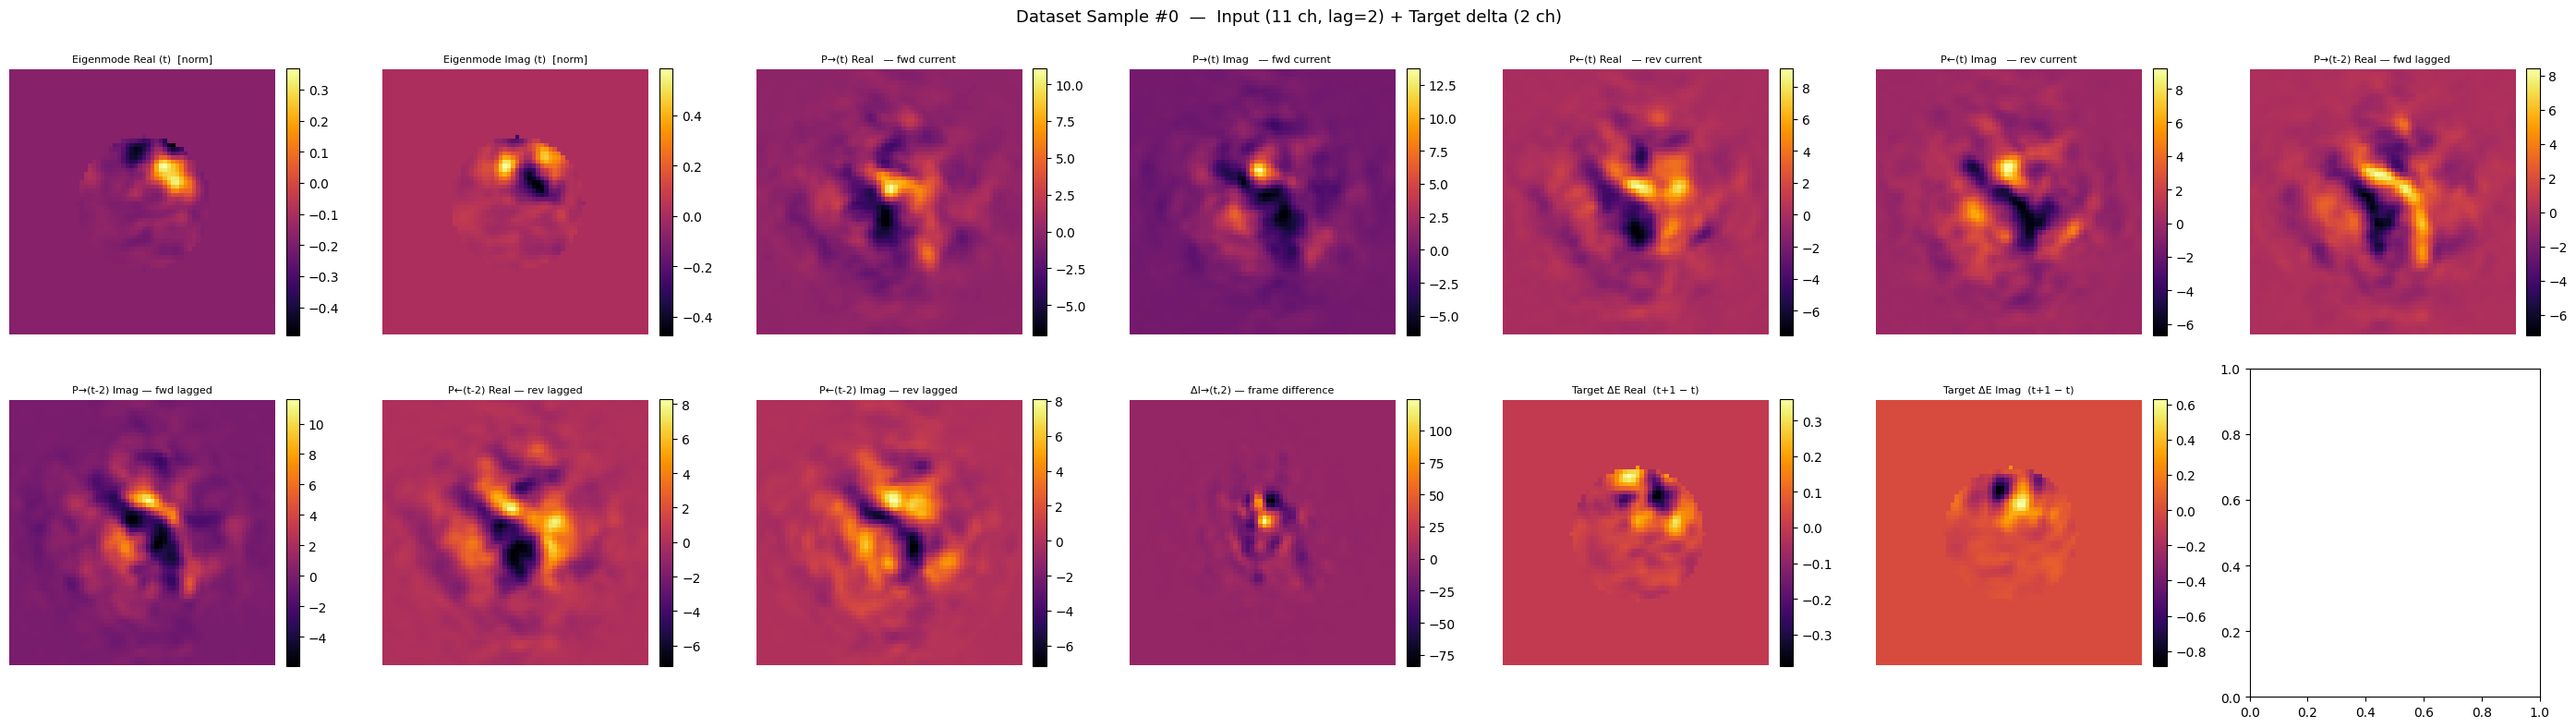

In [216]:

sample_idx = 0   # ← change this to inspect any sample

x_np = X[sample_idx].numpy()   # (H, W, 11)
y_np = Y[sample_idx].numpy()   # (H, W, 2)

channel_labels = [
    "Eigenmode Real (t)  [norm]",
    "Eigenmode Imag (t)  [norm]",
    f"P→(t) Real   — fwd current",
    f"P→(t) Imag   — fwd current",
    f"P←(t) Real   — rev current",
    f"P←(t) Imag   — rev current",
    f"P→(t-{LAG}) Real — fwd lagged",
    f"P→(t-{LAG}) Imag — fwd lagged",
    f"P←(t-{LAG}) Real — rev lagged",
    f"P←(t-{LAG}) Imag — rev lagged",
    f"ΔI→(t,{LAG}) — frame difference",
    "Target ΔE Real  (t+1 − t)",
    "Target ΔE Imag  (t+1 − t)",
]

all_data = [x_np[..., c] for c in range(11)] + [y_np[..., c] for c in range(2)]

fig, axes = plt.subplots(2, 7, figsize=(28, 8))
fig.suptitle(f"Dataset Sample #{sample_idx}  —  Input (11 ch, lag={LAG}) + Target delta (2 ch)", fontsize=13)

for ax, arr, lbl in zip(axes.flat, all_data, channel_labels):
    im = ax.imshow(arr, cmap="inferno", aspect="equal")
    ax.set_title(lbl, fontsize=8)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


Prepare the dataset for training/test

In [272]:
n_total = int(0.50*X.shape[0])
n_train = int(0.85*n_total)
batch_size = 10

x_train =  X[:n_train]
x_test =  X[n_train:n_total]

y_train = Y[:n_train]
y_test = Y[n_train:n_total]

N = x_train.shape[2]

training_set = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
testing_set = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size, shuffle=False)

In [273]:
n_train

4249

In [274]:
x_batch, y_batch = next(iter(training_set))
print(x_batch.shape)

torch.Size([10, 64, 64, 6])


Instantiate the FNO architecture

In [275]:

epochs = 50

# These control the step-wise updates on the LR
learn_rate = 0.001  # initial LR
decay_rate = 0.001  # initial weight decay
step_size  = 12     # epochs between LR decay steps
gamma      = 0.5    # LR decay factor

# FNO architecture
modes1      = 36
modes2      = 36
width       = 32
n_layers    = 2
retrain_fno = 99

# 11-channel input:
#   0,1  : eigenmode Re/Im at t  (normalised)
#   2,3  : P→(t) Re/Im           current forward probe
#   4,5  : P←(t) Re/Im           current reverse probe
#   6,7  : P→(t-1) Re/Im         previous forward probe
#   8,9  : P←(t-1) Re/Im         previous reverse probe
#   10   : ΔI→(t)                 forward frame difference
input_chans  = 6
output_chans = 2

# Physical parameters
size     = 0.45     # simulation window (m)
lensSize = 0.1125   # size/4

fno_architecture = {"modes1": modes1, "modes2": modes2, "width": width, "n_layers": n_layers,
                    "retrain_fno": retrain_fno, "input_chans": input_chans, "output_chans": output_chans}


Load up GPU (if not already done so)

In [276]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5060 Laptop GPU
Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)


To avoid confusion, we apply an aperture on the output predicted channel. 

In [277]:
def torch_circ_aperture(field_batch: torch.Tensor, size: float, lensSize: float) -> torch.Tensor:
    """
    Applies a circular aperture to a batch of complex fields represented
    as real/imaginary channels.

    Parameters
    ----------
    field_batch : torch.Tensor  shape (batch, H, W, C)
                  where C=2 holds [real, imag] channels
    size        : float — physical side length of the window (metres)
    lensSize    : float — aperture radius (metres)

    Returns
    -------
    torch.Tensor — same shape as field_batch, zeroed outside the aperture
    """
    _, H, W, _ = field_batch.shape
    device = field_batch.device

    # Build physical coordinate axes centred at zero — same convention as LightPipes
    x = torch.linspace(-size / 2, size / 2, W, device=device)
    y = torch.linspace(-size / 2, size / 2, H, device=device)
    yy, xx = torch.meshgrid(y, x, indexing="ij")   # (H, W)

    # Binary mask: 1 inside aperture, 0 outside
    mask = (xx**2 + yy**2 <= lensSize**2).float()  # (H, W)
    mask = mask.unsqueeze(0).unsqueeze(-1)          # (1, H, W, 1) — broadcasts over batch and channels

    return field_batch * mask




In [279]:
y_test.shape

torch.Size([750, 64, 64, 2])

Now train the FNO

In [280]:
use_mse_loss = False
use_overlap_loss = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Instantiate the model and move to GPU
fno = FNO2d(fno_architecture, device=device)

optim = Adam(fno.parameters(), lr=learn_rate, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=step_size, gamma=gamma)

if use_mse_loss:
    loss = torch.nn.MSELoss()
elif use_overlap_loss:
    loss = overlap_loss
else:
    # Build a weight map once before the loop
    freq_weights = make_freq_weights(N, k_cutoff_frac=0.99, alpha=2.0, device=device)

freq_print = 1

n_train_batches = len(training_set)
n_test_batches = len(testing_set)

train_mse_history = []
test_rel_l2_history = []

for epoch in range(epochs):

    # Evaluate the training metric
    fno.train()
    train_mse = 0.0

    for step, (input_batch, delta_batch) in enumerate(training_set):
        input_batch = input_batch.to(device)   # (B, H, W, 6)
        delta_batch = delta_batch.to(device)   # (B, H, W, 2) — true ΔE

        optim.zero_grad()

        # Predict ΔE and apply aperture
        delta_pred_batch = torch_circ_aperture(fno(input_batch), size=size, lensSize=lensSize)  # (B, H, W, 2)

        # Reconstruct E_{t+1} = E_t + ΔE  (channels 0,1 of input are the eigenmode at t)
        output_pred_batch = reconstruct_from_delta(input_batch[..., :2], delta_pred_batch)   # (B, H, W, 2)
        output_batch      = reconstruct_from_delta(input_batch[..., :2], delta_batch)        # (B, H, W, 2)

        if use_mse_loss or use_overlap_loss:
            loss_f = loss(output_pred_batch, output_batch)
        else:
            loss_f = spectral_relative_l2(output_pred_batch, output_batch, freq_weights)

        loss_f.backward()
        optim.step()
        train_mse += loss_f.item()

    train_mse /= n_train_batches
    print("Training batches computed")

    scheduler.step()

    with torch.no_grad():
        fno.eval()
        test_relative_l2 = 0.0
        for step, (input_batch, delta_batch) in enumerate(testing_set):
            input_batch = input_batch.to(device)   # (B, H, W, 6)
            delta_batch = delta_batch.to(device)   # (B, H, W, 2) — true ΔE

            # Predict ΔE and apply aperture
            delta_pred_batch = torch_circ_aperture(fno(input_batch), size=size, lensSize=lensSize)  # (B, H, W, 2)

            # Reconstruct E_{t+1} = E_t + ΔE
            output_pred_batch = reconstruct_from_delta(input_batch[..., :2], delta_pred_batch)   # (B, H, W, 2)
            output_batch      = reconstruct_from_delta(input_batch[..., :2], delta_batch)        # (B, H, W, 2)

            if use_mse_loss:
                loss_f = (torch.mean((output_pred_batch - output_batch) ** 2) / torch.mean(output_batch ** 2)) ** 0.5 * 100
            elif use_overlap_loss:
                loss_f = loss(output_pred_batch, output_batch)
            else:
                loss_f = spectral_relative_l2(output_pred_batch, output_batch, freq_weights)

            test_relative_l2 += loss_f.item()

        test_relative_l2 /= n_test_batches

    train_mse_history.append(train_mse)
    test_rel_l2_history.append(test_relative_l2)

    if epoch % freq_print == 0:
        print(f"========= Epoch {epoch+1}/{epochs} Summary ========= Train Loss: {train_mse:.6f} | Mean Test Loss: {test_relative_l2:.4f}\n")


Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)
Training batches computed
========= Epoch 1/50 Summary ========= Train Loss: 0.150987 | Mean Test Loss: 0.1313

Training batches computed
========= Epoch 2/50 Summary ========= Train Loss: 0.130666 | Mean Test Loss: 0.1284

Training batches computed
========= Epoch 3/50 Summary ========= Train Loss: 0.128816 | Mean Test Loss: 0.1275

Training batches computed
========= Epoch 4/50 Summary ========= Train Loss: 0.128556 | Mean Test Loss: 0.1268

Training batches computed
========= Epoch 5/50 Summary ========= Train Loss: 0.127871 | Mean Test Loss: 0.1274

Training batches computed
========= Epoch 6/50 Summary ========= Train Loss: 0.127996 | Mean Test Loss: 0.1274

Training batches computed
========= Epoch 7/50 Summary ========= Train Loss: 0.127769 | Mean Test Loss: 0.1262

Training batches computed
========= Epoch 8/50 Summary ========= Train Loss: 0.127519 | Mean Test Loss: 0.1268

Training batches computed
========= Epoch 9/50 S

Save the model (if applicable)

In [281]:

models_dir = "trained_models_eigen"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "fno_eigen.pth")

torch.save({
    "model_state_dict": fno.state_dict(),
    "optimizer_state_dict": optim.state_dict(),
    "fno_architecture": fno_architecture,
    "epochs": epochs,
    "train_mse_history": train_mse_history,
    "test_rel_l2_history": test_rel_l2_history,
}, model_path)

print(f"Model saved to {model_path}")

Model saved to trained_models_eigen\fno_eigen.pth


Make a plot

Plot saved to training_plots/training_curves.png


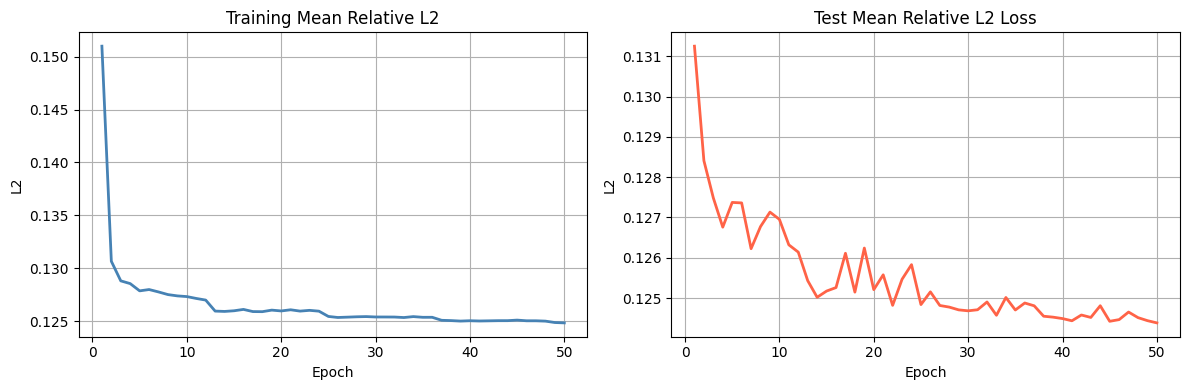

In [282]:
import os

epochs=epochs
epochs_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_mse_history, color='steelblue', linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("L2")
axes[0].set_title("Training Mean Relative L2")
axes[0].grid(True)

axes[1].plot(epochs_range, test_rel_l2_history, color='tomato', linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("L2")
axes[1].set_title("Test Mean Relative L2 Loss")
axes[1].grid(True)

plt.tight_layout()

plots_dir = "training_plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, "training_curves.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to {plots_dir}/training_curves.png")

plt.show()

# Inference

How does our network do on infering the propagation of the network?

In [283]:
# Assign device (if applicable)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Load the model checkpoint (if applicable)

checkpoint = torch.load("trained_models_eigen/fno_eigen.pth")
fno = FNO2d(checkpoint["fno_architecture"], device=device)
fno.load_state_dict(checkpoint["model_state_dict"])

sample_index = 50
input_sample = x_test[sample_index, :, :, :].unsqueeze(0).to(device)

# Extract the propagated field distance for reference

output_dist = input_sample[0,0,0,0]
print(output_dist)

fno.eval()
with torch.no_grad():
    output_pred = fno(input_sample)

# Reconstruct field from real and imaginary components

output_pred = output_pred.squeeze(0).cpu().numpy()
output_field = output_pred[..., 0] + 1j*output_pred[..., 1]

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5060 Laptop GPU
Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)
tensor(-0.1734, device='cuda:0')


In [284]:
checkpoint["fno_architecture"]

{'modes1': 36,
 'modes2': 36,
 'width': 32,
 'n_layers': 2,
 'retrain_fno': 99,
 'input_chans': 6,
 'output_chans': 2}

Plot the input/output prediction

In [285]:

sample_index = 10
size = 0.45
lensSize = size / 4

# --- Run inference ---
input_sample = x_test[sample_index].unsqueeze(0).to(device)  # (1, H, W, 6)

fno.eval()
with torch.no_grad():
    # FNO predicts ΔE; apply aperture
    delta_pred = torch_circ_aperture(fno(input_sample), size=size, lensSize=lensSize)  # (1, H, W, 2)

# --- Extract eigenmode at t from input (channels 0, 1) ---
input_np       = x_test[sample_index].cpu().numpy()          # (H, W, 6)
eigenmode_in_r = input_np[..., 0]                            # E_t real
eigenmode_in_i = input_np[..., 1]                            # E_t imag
eigenmode_in   = eigenmode_in_r + 1j * eigenmode_in_i
gaussian_fwd   = input_np[..., 2] + 1j * input_np[..., 3]   # Gaussian forward

# --- Reconstruct true E_{t+1} = E_t + ΔE_true ---
delta_true_np  = y_test[sample_index].cpu().numpy()          # (H, W, 2) — true ΔE
eigenmode_true = (eigenmode_in_r + delta_true_np[..., 0]) + 1j * (eigenmode_in_i + delta_true_np[..., 1])

# --- Reconstruct predicted E_{t+1} = E_t + ΔE_pred ---
delta_pred_np  = delta_pred.squeeze(0).cpu().numpy()         # (H, W, 2) — predicted ΔE
eigenmode_pred = (eigenmode_in_r + delta_pred_np[..., 0]) + 1j * (eigenmode_in_i + delta_pred_np[..., 1])

print(f"Input eigenmode range  : [{np.abs(eigenmode_in).min():.4f}, {np.abs(eigenmode_in).max():.4f}]")
print(f"True output range      : [{np.abs(eigenmode_true).min():.4f}, {np.abs(eigenmode_true).max():.4f}]")
print(f"Predicted output range : [{np.abs(eigenmode_pred).min():.4f}, {np.abs(eigenmode_pred).max():.4f}]")


Input eigenmode range  : [0.0197, 0.7551]
True output range      : [0.0382, 0.7203]
Predicted output range : [0.0337, 0.4473]


<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_2108\1704093334.py:9: SyntaxWarning: invalid escape sequence '\h'
  (eigenmode_pred, "Predicted Output Eigenmode $\hat{E}_{t+1}$"),


Plot saved to inference_plots/inference_sample10.png


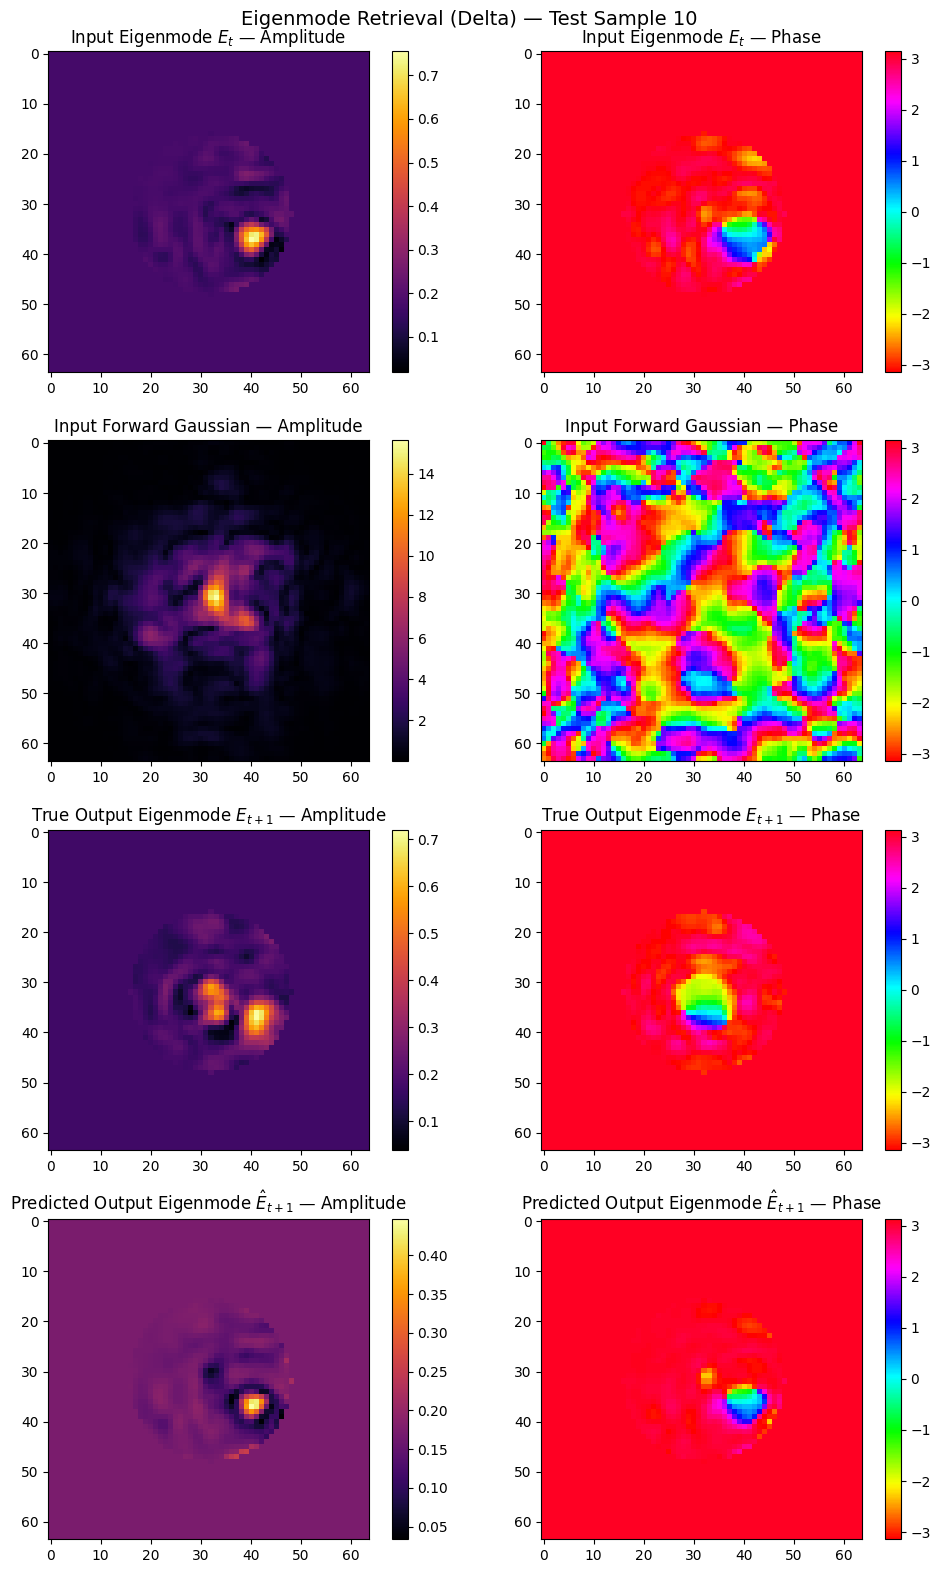

In [286]:

# --- Plot reconstructed fields ---
fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle(f"Eigenmode Retrieval (Delta) — Test Sample {sample_index}", fontsize=14)

rows = [
    (eigenmode_in,   "Input Eigenmode $E_t$"),
    (gaussian_fwd,   "Input Forward Gaussian"),
    (eigenmode_true, "True Output Eigenmode $E_{t+1}$"),
    (eigenmode_pred, "Predicted Output Eigenmode $\hat{E}_{t+1}$"),
]

for i, (field, title) in enumerate(rows):
    im_amp = axes[i, 0].imshow(np.abs(field), cmap='inferno')
    axes[i, 0].set_title(f"{title} — Amplitude")
    plt.colorbar(im_amp, ax=axes[i, 0])

    im_ph = axes[i, 1].imshow(np.angle(field), cmap='hsv')
    axes[i, 1].set_title(f"{title} — Phase")
    plt.colorbar(im_ph, ax=axes[i, 1])

plt.tight_layout()

plots_dir = "inference_plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, f"inference_sample{sample_index}.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to {plots_dir}/inference_sample{sample_index}.png")

plt.show()


Compute the "identity baseline." This entails taking the fidelities between the eigenmodes at consecutive timesteps. Do this with the dataset and with the model predictions.

In [287]:

# --- Identity baseline and model fidelity over the full test set ---
# Note: testing_set yields (input, delta), so E_{t+1} must be reconstructed
# as E_t + ΔE before computing the overlap.

identity_fidelities_test = []
identity_fidelities_pred = []

fno.eval()
with torch.no_grad():
    for input_batch, delta_batch in testing_set:
        input_batch = input_batch.to(device)   # (B, H, W, 6)
        delta_batch = delta_batch.to(device)   # (B, H, W, 2) — true ΔE

        em_t = input_batch[..., :2]  # eigenmode at t, (B, H, W, 2)

        # Reconstruct ground-truth E_{t+1} = E_t + ΔE_true
        output_batch = reconstruct_from_delta(em_t, delta_batch)          # (B, H, W, 2)
        B_field      = torch.complex(output_batch[..., 0], output_batch[..., 1])  # (B, H, W)
        norm_B_sq    = (B_field.abs() ** 2).sum(dim=(-2, -1))             # (B,)

        # ── Identity baseline: E_t  vs  E_{t+1} ──────────────────────────────
        A         = torch.complex(em_t[..., 0], em_t[..., 1])             # (B, H, W)
        inner_id  = (A.conj() * B_field).sum(dim=(-2, -1))
        norm_A_sq = (A.abs() ** 2).sum(dim=(-2, -1))
        F_id      = inner_id.abs() ** 2 / (norm_A_sq * norm_B_sq + 1e-8)  # (B,)
        identity_fidelities_test.extend(F_id.cpu().tolist())

        # ── Model: reconstruct Ê_{t+1} = E_t + ΔE_pred ───────────────────────
        delta_pred_batch  = torch_circ_aperture(fno(input_batch), size=size, lensSize=lensSize)
        output_pred_batch = reconstruct_from_delta(em_t, delta_pred_batch)  # (B, H, W, 2)
        C         = torch.complex(output_pred_batch[..., 0], output_pred_batch[..., 1])  # (B, H, W)
        inner_pred = (C.conj() * B_field).sum(dim=(-2, -1))
        norm_C_sq  = (C.abs() ** 2).sum(dim=(-2, -1))
        F_pred     = inner_pred.abs() ** 2 / (norm_C_sq * norm_B_sq + 1e-8)  # (B,)
        identity_fidelities_pred.extend(F_pred.cpu().tolist())

identity_fidelities_test = np.array(identity_fidelities_test)
identity_fidelities_pred = np.array(identity_fidelities_pred)

print(f"Samples evaluated          : {len(identity_fidelities_test)}")
print(f"Identity baseline  — mean F : {identity_fidelities_test.mean():.4f}  |  std: {identity_fidelities_test.std():.4f}")
print(f"Model predictions  — mean F : {identity_fidelities_pred.mean():.4f}  |  std: {identity_fidelities_pred.std():.4f}")


Samples evaluated          : 750
Identity baseline  — mean F : 0.8358  |  std: 0.1448
Model predictions  — mean F : 0.8756  |  std: 0.0736
